# Day 08. Exercise 04
# Regression

## 0. Imports

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import numpy as np

## 1. Preprocessing

1. Read the file [`checker_regression.csv`](https://drive.google.com/file/d/1L8auBzJEghWFewznhhFpcrqxW4GqcfRY/view?usp=sharing).
2. Fill the missing values in it with `0`.
3. Make a split of your dataset on train and test with parameters `test_size=0.2`.

In [27]:
df = pd.read_csv('data/checker_regression.csv')
df = df.groupby('uid').mean().reset_index()

print("До заполнения пропусков:")
print(df.info())

df = df.fillna(0)

print("\nПосле заполнения пропусков:")
print(df.info())

До заполнения пропусков:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   uid          29 non-null     object 
 1   num_commits  29 non-null     float64
 2   pageviews    11 non-null     float64
 3   AVG(diff)    18 non-null     float64
dtypes: float64(3), object(1)
memory usage: 1.0+ KB
None

После заполнения пропусков:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   uid          29 non-null     object 
 1   num_commits  29 non-null     float64
 2   pageviews    29 non-null     float64
 3   AVG(diff)    29 non-null     float64
dtypes: float64(3), object(1)
memory usage: 1.0+ KB
None


In [28]:
X = df[['num_commits', 'pageviews']]
y = df['AVG(diff)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

print("Размеры выборок:")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

Размеры выборок:
X_train: (23, 2), X_test: (6, 2)


## 2. Crossvalidation

1. Write a function `crossval` that takes as arguments: `n_splits` for `KFold()`, `X`, `y`, model instantiated class with the parameters of the model (keep in mind: `random_state=21`) and returns for a given model class a result like this:

```
train -  2696.4496895424836   |   test -  1589.9979527104958
train -  2660.957874001452   |   test -  2075.102636027137
train -  2847.315529246795   |   test -  320.911928168403
train -  2500.7691099659237   |   test -  4132.461382030178
train -  2643.927917295123   |   test -  2237.8140952197878
train -  2396.295678819444   |   test -  4509.650064742476
train -  2003.402267924976   |   test -  8403.491474908551
train -  2531.876094212613   |   test -  3135.944102735099
train -  2683.1795186023123   |   test -  1796.01426292594
train -  2537.1192483996338   |   test -  3439.29824116941
Average RMSE on crossval is 3164.0686140637476
```

2. Run the function for `LinearRegression`, `DecisionTreeRegressor`, `RandomForestRegressor`. You may choose the parameters by yourself, but find the good enough for you.

In [29]:
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error


def crossval(n_splits, X, y, model):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=21)
    
    test_rmse_list = []
    
    for train_index, test_index in kf.split(X):
        X_fold_train, X_fold_test = X.iloc[train_index], X.iloc[test_index]
        y_fold_train, y_fold_test = y.iloc[train_index], y.iloc[test_index]

        model.fit(X_fold_train, y_fold_train)

        train_preds = model.predict(X_fold_train)
        test_preds = model.predict(X_fold_test)
        
        train_rmse = root_mean_squared_error(y_fold_train, train_preds)
        test_rmse = root_mean_squared_error(y_fold_test, test_preds)
        
        test_rmse_list.append(test_rmse)
        
        print(f"train -  {train_rmse:.15f}   |   test -  {test_rmse:.15f}")
        
    avg_test_rmse = np.mean(test_rmse_list)
    print(f"Average RMSE on crossval is {avg_test_rmse:.15f}\n")

In [30]:
print("Linear Regression")
lr = LinearRegression()
crossval(10, X_train, y_train, lr)

Linear Regression
train -  53.333510964916918   |   test -  115.239431836386700
train -  62.409919772255556   |   test -  69.358087947330219
train -  64.751464232441307   |   test -  52.395419621714417
train -  64.040949816277546   |   test -  78.188108214072273
train -  63.574089717062193   |   test -  58.669554693832161
train -  65.401545601814391   |   test -  32.100688546741218
train -  64.406002455571610   |   test -  48.593228781922150
train -  61.215472663804725   |   test -  82.417341941636522
train -  64.693722633045070   |   test -  43.811633455444721
train -  62.801957400620140   |   test -  70.472289005354540
Average RMSE on crossval is 65.124578404443497



In [31]:

print("Decision Tree Regressor")
dtr = DecisionTreeRegressor(max_depth=4, random_state=21)
crossval(10, X_train, y_train, dtr)

Decision Tree Regressor
train -  19.756827933653724   |   test -  63.210125771113603
train -  20.876122724299165   |   test -  82.258108910194878
train -  22.063461184602122   |   test -  11.518137870333035
train -  21.742264634314694   |   test -  8.603132504436330
train -  15.222075077495283   |   test -  80.256619664673138
train -  21.569529200867827   |   test -  15.202795795510772
train -  21.347979223599054   |   test -  40.587929240107833
train -  21.569529200867827   |   test -  37.190388543278225
train -  20.395386545197969   |   test -  30.812177990203800
train -  13.121372766613382   |   test -  69.119687860985024
Average RMSE on crossval is 43.875910415083659



In [32]:
print("Random Forest Regressor")
rfr = RandomForestRegressor(n_estimators=100, max_depth=4, random_state=21)
crossval(10, X_train, y_train, rfr)

Random Forest Regressor
train -  23.648754475444115   |   test -  78.432530449887665
train -  26.091799230128100   |   test -  81.452620533058436
train -  26.692847022939663   |   test -  4.964962393869823
train -  27.938156732675584   |   test -  17.268276843273327
train -  27.005301102759450   |   test -  67.153349001952435
train -  24.789515496914206   |   test -  40.814617260561612
train -  25.660143262934877   |   test -  55.600183231796358
train -  26.967835217656109   |   test -  26.718341957915467
train -  25.244205818351759   |   test -  19.810553458677774
train -  19.904410452532616   |   test -  69.937292146532542
Average RMSE on crossval is 46.215272727752541



## 3. Predictions and evaluation

1. Make predictions for the test dataset using each of the three models with the finalized parameters.
2. Draw a plot for each of the models where the `x-axis` is the actual average difference and the `y-axis` is the prediction made by a model.
3. How would plot look like in the ideal case? Put the answer to the markdown cell in the end of the section.

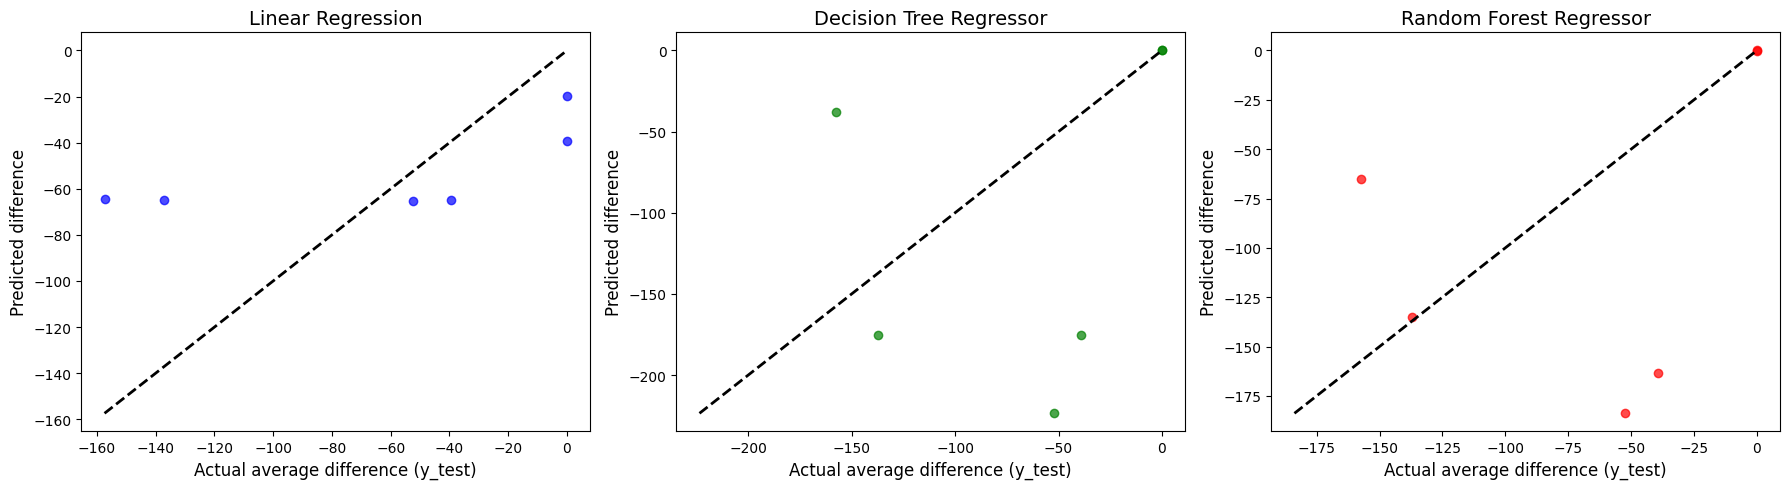

In [33]:
lr_final = LinearRegression()
lr_final.fit(X_train, y_train)
lr_pred = lr_final.predict(X_test)

dtr_final = DecisionTreeRegressor(max_depth=4, random_state=21)
dtr_final.fit(X_train, y_train)
dtr_pred = dtr_final.predict(X_test)

rfr_final = RandomForestRegressor(n_estimators=100, max_depth=4, random_state=21)
rfr_final.fit(X_train, y_train)
rfr_pred = rfr_final.predict(X_test)


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

def plot_predictions(ax, y_true, y_pred, title, color):
    ax.scatter(y_true, y_pred, color=color, alpha=0.7)
    
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2)
    
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Actual average difference (y_test)', fontsize=12)
    ax.set_ylabel('Predicted difference', fontsize=12)

plot_predictions(axes[0], y_test, lr_pred, 'Linear Regression', 'blue')
plot_predictions(axes[1], y_test, dtr_pred, 'Decision Tree Regressor', 'green')
plot_predictions(axes[2], y_test, rfr_pred, 'Random Forest Regressor', 'red')

plt.tight_layout()
plt.show()

How would plot look like in the ideal case?

В идеальном случае все точки графика легли бы на пунктирную линию (то есть предсказания совпали бы с реальностью)